In [26]:
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torchvision import datasets, transforms

In [27]:
class NoisyFashionMNIST(torch.utils.data.Dataset):
    def __init__(self, root, train, mean, std, download):
        self.dataset = datasets.FashionMNIST(
            root=root,
            train=train,
            download=download,
            transform=transforms.Compose([
                transforms.ToTensor()
            ])
        )
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        target, _ = self.dataset[index]
        input = self.add_gaussian_noise(target)
        return input, target

    def add_gaussian_noise(self, image):
        noise = torch.randn_like(image) * self.std + self.mean
        noisy_img = image + noise
        return torch.clamp(noisy_img, 0, 1)


In [28]:
mean = 0
std = 0.1
batch_size = 10

train_set = NoisyFashionMNIST(
    root='./data',
    train=True,
    mean=mean,
    std=std,
    download=True
)
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

test_set = NoisyFashionMNIST(
    root='./data',
    train=False,
    mean=mean,
    std=std,
    download=True
)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False
)

In [29]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            # 1x28x28 > 16x14x14
            # nn.BatchNorm2d(16),
            nn.ReLU(),
            # nn.Dropout(0.1),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            # 16x14x14 > 32x7x7
            # nn.BatchNorm2d(32),
            nn.ReLU(),
            # nn.Dropout(0.1),
            nn.Conv2d(32, 64, kernel_size=7),
            # nn.BatchNorm2d(64)
            # nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            # 32x7x7 > 64x4x4
            # nn.ReLU(),
            # nn.Dropout(0.1),
            # nn.Conv2d(64, 128, kernel_size=4)
            # # 64x4x4 > 128x1x1
        )
        self.decoder = nn.Sequential(
            # nn.ConvTranspose2d(128, 64, kernel_size=4),
            # nn.ReLU(),
            # nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ConvTranspose2d(64, 32, kernel_size=7),
            # nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            # nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [30]:
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    print("GPU not available, using CPU")
    device = torch.device('cpu')

model = Autoencoder()
model.to(device)
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

CUDA version: 12.6
GPU name: Tesla T4


In [31]:
num_epochs = 5

train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (noisy_imgs, clean_imgs) in enumerate(train_loader):
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        # forward
        outputs = model(noisy_imgs)
        loss = loss_function(outputs, clean_imgs)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if batch_idx % 500 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.6f}')

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] - Average Loss: {avg_loss:.4f}\n')

Epoch [1/5], Step [0/6000], Loss: 0.225825
Epoch [1/5], Step [500/6000], Loss: 0.017433
Epoch [1/5], Step [1000/6000], Loss: 0.016353
Epoch [1/5], Step [1500/6000], Loss: 0.018495
Epoch [1/5], Step [2000/6000], Loss: 0.011987
Epoch [1/5], Step [2500/6000], Loss: 0.011614
Epoch [1/5], Step [3000/6000], Loss: 0.013637
Epoch [1/5], Step [3500/6000], Loss: 0.011899
Epoch [1/5], Step [4000/6000], Loss: 0.011337
Epoch [1/5], Step [4500/6000], Loss: 0.009645
Epoch [1/5], Step [5000/6000], Loss: 0.009897
Epoch [1/5], Step [5500/6000], Loss: 0.010259
Epoch [1/5] - Average Loss: 0.0167

Epoch [2/5], Step [0/6000], Loss: 0.007001
Epoch [2/5], Step [500/6000], Loss: 0.009022
Epoch [2/5], Step [1000/6000], Loss: 0.014371
Epoch [2/5], Step [1500/6000], Loss: 0.009609
Epoch [2/5], Step [2000/6000], Loss: 0.007934
Epoch [2/5], Step [2500/6000], Loss: 0.007488
Epoch [2/5], Step [3000/6000], Loss: 0.011159
Epoch [2/5], Step [3500/6000], Loss: 0.008518
Epoch [2/5], Step [4000/6000], Loss: 0.007321
Epoch 

In [32]:
model.eval()
test_loss = 0.0

with torch.no_grad():
    for noisy_imgs, clean_imgs in test_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        outputs = model(noisy_imgs)
        loss = loss_function(outputs, clean_imgs)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f'Test Loss: {avg_test_loss:.4f}')

Test Loss: 0.0068


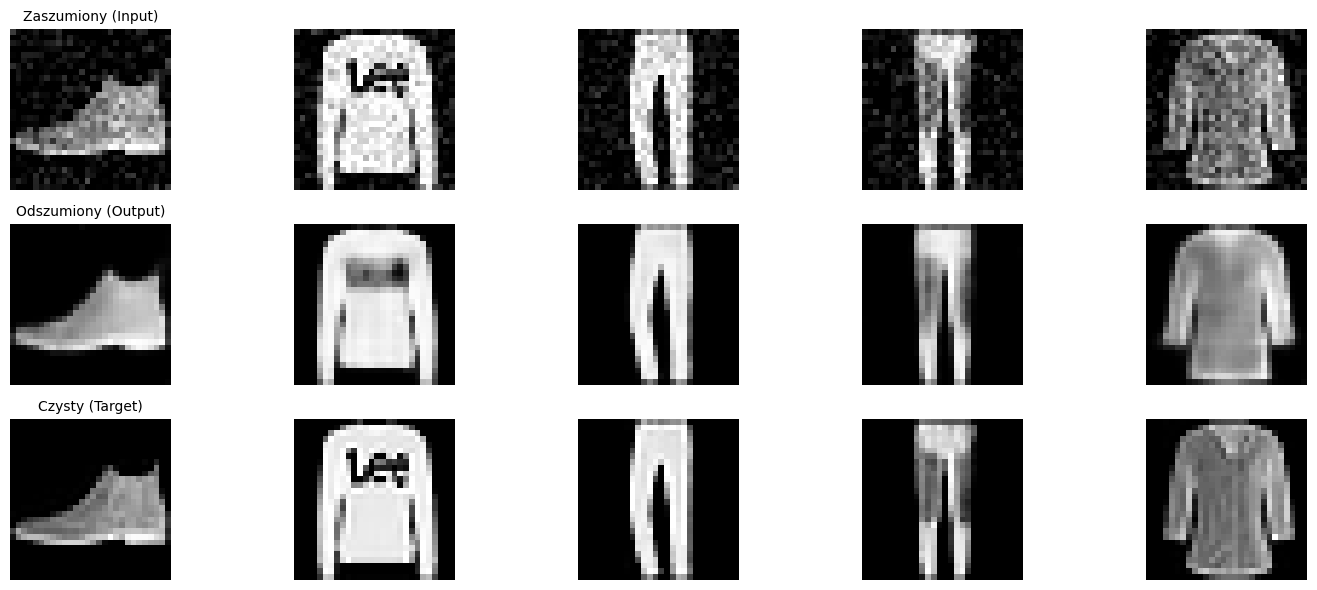

In [33]:
model.eval()
noisy_imgs, clean_imgs = next(iter(test_loader))
noisy_imgs = noisy_imgs.to(device)

with torch.no_grad():
    outputs = model(noisy_imgs)

noisy_imgs = noisy_imgs.cpu()
outputs = outputs.cpu()
clean_imgs = clean_imgs.cpu()

num_images = 5
fig, axes = plt.subplots(3, num_images, figsize=(15, 6))

for i in range(num_images):
    # zaszumiony (input)
    axes[0, i].imshow(noisy_imgs[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Zaszumiony (Input)', fontsize=10)

    # odszumiony przez model (output)
    axes[1, i].imshow(outputs[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Odszumiony (Output)', fontsize=10)

    # czysty (target)
    axes[2, i].imshow(clean_imgs[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Czysty (Target)', fontsize=10)

plt.tight_layout()
plt.show()

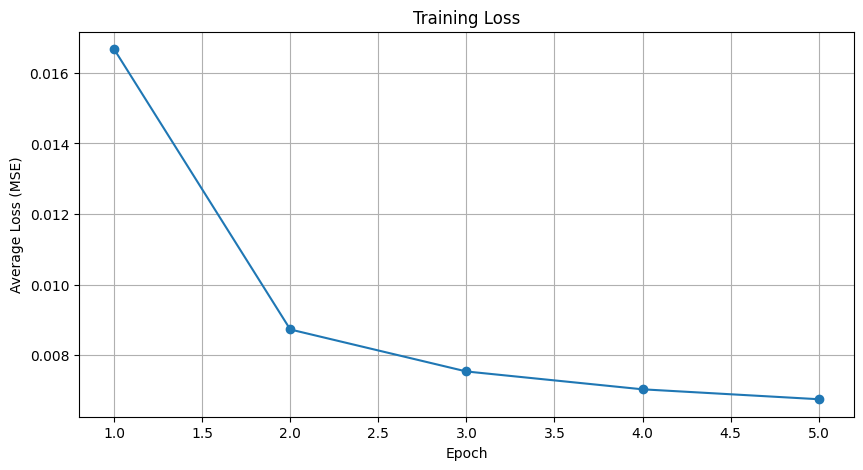

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss (MSE)')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [35]:
torch.save(model.state_dict(), 'autoencoder_model.pth')
print('Model saved as: autoencoder_model.pth')

Model saved as: autoencoder_model.pth
